Starting Grid Search with Lasso. This will take significantly longer than Ridge...


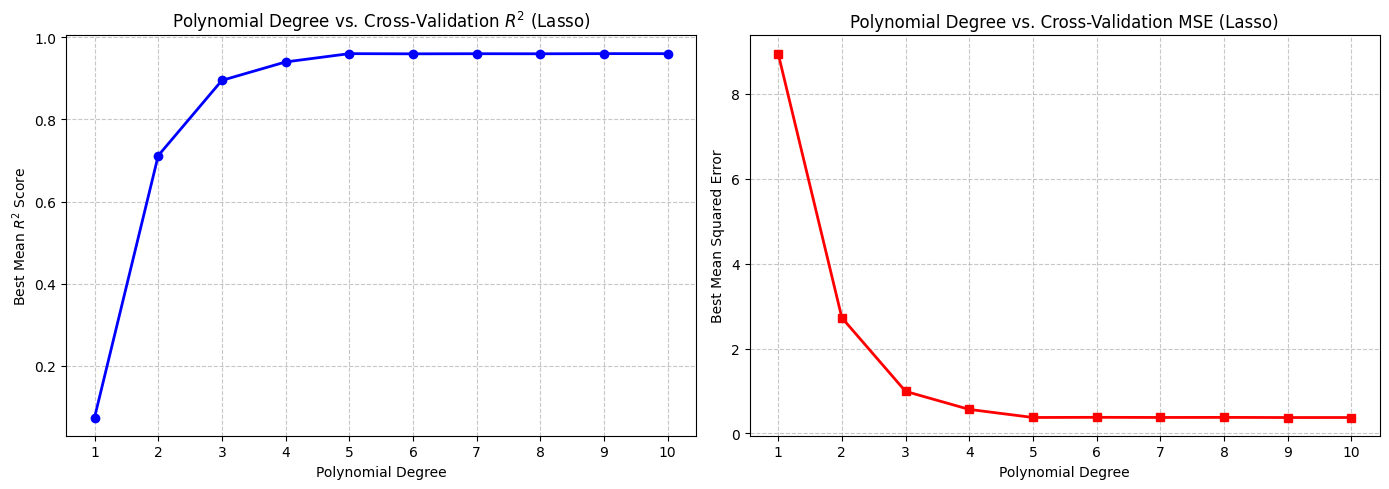

Optimal Polynomial Degree found: 9
Optimal Lasso Alpha found: 0.01
R-squared Score on Train/Test Split: 0.9606

Predictions successfully generated and saved to 'IMT2024078_predictions_lasso.csv'.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings

# Suppress ConvergenceWarnings which are common with Lasso on massive feature spaces
warnings.filterwarnings("ignore")

# 1. Load the dataset
dataset_train = pd.read_csv('IMT2024078_train_var1(in).csv')
X = dataset_train.iloc[:, :-1].values
y = dataset_train.iloc[:, -1].values

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Create a modeling pipeline with Lasso Regression
# max_iter is increased to 10,000 to help the algorithm converge on high degrees
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('lasso', Lasso(max_iter=10000))
])

# 4. Define the parameter grid
# Lasso typically requires smaller alpha values than Ridge
param_grid = {
    'poly__degree': list(range(1, 11)),
    'lasso__alpha': [0.01, 0.1, 1.0]
}

# 5. Set up GridSearchCV with MULTIPLE scoring metrics
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
    refit='r2',
    n_jobs=-1
)

print("Starting Grid Search with Lasso. This will take significantly longer than Ridge...")
grid_search.fit(X_train, y_train)

# 6. Extract and format the results for plotting
results = grid_search.cv_results_
df_results = pd.DataFrame(results)

# Group by degree and take the best R2 score for each degree across the tested alphas
best_per_degree = df_results.loc[df_results.groupby('param_poly__degree')['mean_test_r2'].idxmax()]

degrees = best_per_degree['param_poly__degree'].values.astype(int)
mean_r2 = best_per_degree['mean_test_r2'].values
mean_mse = -1 * best_per_degree['mean_test_neg_mse'].values

# --- Plotting Degree vs R2 and Degree vs MSE ---
plt.figure(figsize=(14, 5))

# Plot 1: Degree vs R2
plt.subplot(1, 2, 1)
plt.plot(degrees, mean_r2, marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Polynomial Degree vs. Cross-Validation $R^2$ (Lasso)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Best Mean $R^2$ Score')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Degree vs MSE
plt.subplot(1, 2, 2)
plt.plot(degrees, mean_mse, marker='s', color='red', linestyle='-', linewidth=2)
plt.title('Polynomial Degree vs. Cross-Validation MSE (Lasso)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Best Mean Squared Error')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 7. Extract the best model and evaluate on the test set
best_model = grid_search.best_estimator_
best_degree = grid_search.best_params_['poly__degree']
best_alpha = grid_search.best_params_['lasso__alpha']

print(f"Optimal Polynomial Degree found: {best_degree}")
print(f"Optimal Lasso Alpha found: {best_alpha}")

y_pred = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred)
print(f"R-squared Score on Train/Test Split: {final_r2:.4f}\n")

# --- Test Set Predictions ---
dataset_unseen = pd.read_csv('IMT2024078_test_var1(in).csv')
X_unseen = dataset_unseen.values

# Predict using the trained best_model
final_predictions = best_model.predict(X_unseen)

# Save the predictions to a CSV file
output_df = pd.DataFrame({'Predicted_Net_Power_Score': final_predictions})
output_df.to_csv('IMT2024078_predictions_lasso.csv', index=False)
print("Predictions successfully generated and saved to 'IMT2024078_predictions_lasso.csv'.")

In [ ]:
# Print the validation scores for each degree
print("\n--- Validation Scores per Degree (Lasso) ---")
for deg, r2, mse in zip(degrees, mean_r2, mean_mse):
    print(f"Degree {deg:2d} | Best CV R2: {r2:.6f} | Best CV MSE: {mse:.6f}")
print("--------------------------------------------\n")


--- Validation Scores per Degree (Lasso) ---
Degree  1 | Best CV R2: 0.074565 | Best CV MSE: 8.942969
Degree  2 | Best CV R2: 0.711812 | Best CV MSE: 2.724848
Degree  3 | Best CV R2: 0.894929 | Best CV MSE: 0.992427
Degree  4 | Best CV R2: 0.939793 | Best CV MSE: 0.567095
Degree  5 | Best CV R2: 0.959977 | Best CV MSE: 0.377199
Degree  6 | Best CV R2: 0.959545 | Best CV MSE: 0.380720
Degree  7 | Best CV R2: 0.959828 | Best CV MSE: 0.377831
Degree  8 | Best CV R2: 0.959661 | Best CV MSE: 0.379363
Degree  9 | Best CV R2: 0.960030 | Best CV MSE: 0.376017
Degree 10 | Best CV R2: 0.959955 | Best CV MSE: 0.376638
--------------------------------------------

